# **ANÁLISIS DE LOS DATOS**


## **0. Librerías**

In [1]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, regexp_replace, when, mean, count, desc, round, sum, variance, stddev, year
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## **1. Descarga del datase**

## **2. Creación de la sesión de Spark**
Es necesario especificar la codificación para que Spark no lea el dataset como strings. Mediante `df_raw.printSchema()` comprobamos que los datos se han cargado correctamente.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AirbnbAnalisis_Safe") \
    .master("spark://spark-master:7077") \
    .config("spark.executor.memory", "450m") \
    .config("spark.executor.cores", "1") \
    .config("spark.driver.memory", "512m") \
    .getOrCreate()

print("Nueva sesión LIMPIA iniciada")

hdfs_path = "hdfs://spark-master:9000/data/airbnb"
df_raw = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .option("quote", "\"") \
    .csv(f"{hdfs_path}/Listings.csv")

print(f"Filas: {df_raw.count()}")

25/11/30 19:29:46 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Nueva sesión LIMPIA iniciada


[Stage 2:>                                                          (0 + 1) / 1]

Filas: 279712


In [4]:
try:
    df_listings = spark.read.parquet("hdfs://spark-master:9000/data/processed/listings")
    df_reviews = spark.read.parquet("hdfs://spark-master:9000/data/processed/reviews")
    print("Datos procesados cargados desde HDFS")
    
except Exception:
    print("No se encontraron datos procesados, leyendo crudos...")
    df_listings = spark.read.csv("hdfs://spark-master:9000/data/airbnb/Listings.csv", 
                                 header=True, inferSchema=True, quote="\"", escape="\"", multiLine=True)
    df_reviews = spark.read.csv("hdfs://spark-master:9000/data/airbnb/Reviews.csv", 
                                header=True, inferSchema=True, quote="\"", escape="\"", multiLine=True)
    print("Datos crudos cargados desde HDFS")

df_listings.cache()

Datos procesados cargados desde HDFS


25/11/30 19:30:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


DataFrame[listing_id: int, name: string, host_id: int, host_since: date, host_location: string, host_response_time: string, host_response_rate: double, host_acceptance_rate: double, host_is_superhost: string, host_total_listings_count: int, host_has_profile_pic: string, host_identity_verified: string, neighbourhood: string, district: string, city: string, latitude: double, longitude: double, property_type: string, room_type: string, accommodates: int, bedrooms: int, amenities: string, price: double, minimum_nights: int, maximum_nights: int, review_scores_rating: int, review_scores_accuracy: int, review_scores_cleanliness: int, review_scores_checkin: int, review_scores_communication: int, review_scores_location: int, review_scores_value: int, instant_bookable: string]

## **3. Consultas analíticas**

### **3.1. ¿Cómo cambia el precio medio por noche según el tipo de alojamiento y el barrio?**
**Objetivo:** Identificar diferencias relevantes de precio en función de ubicación y tipología.

**Utilidad:** Permite detectar zonas populares, oportunidades de inversión y estrategias para nuevos hosts.

In [5]:
# Seleccionamos las columnas en las que estamos interesados.
df = df_raw.select(
    "city",
    "neighbourhood",
    "property_type",
    "price"
)
# Eliminamos filas con valores faltantes o NaNs.
df = df.na.drop(subset=["price", "neighbourhood", "property_type", "city"])

# Limpiamos la columna "price" de simbolos que no sean números.
df = df.withColumn("price_clean",
                   regexp_replace(col("price"), "[^0-9.]", "").cast("double")) \
       .drop("price") \
       .withColumnRenamed("price_clean", "price")

# Filtramos outliers (percentil 99).
price_99 = df.stat.approxQuantile("price", [0.99], 0.01)[0]
df = df.filter(col("price") <= price_99 * 1.5)

# Comprobamos cuanto ha cambiado el dataset.
print(f"Listings after cleaning: {df.count():,}")

[Stage 8:>                                                          (0 + 1) / 1]

Listings after cleaning: 279,712


No parece haber outliers.

In [6]:
# Escogemos la ciudad más popular (París) para realizar el análisis.
ciudad = df.groupBy("city").count().orderBy(desc("count")).first()["city"]
df_ciudad = df.filter(col("city") == ciudad)

# Media de precio por barrio Parisino.
media_price_x_neighbourhood = (df_ciudad
    .groupBy("neighbourhood")
    .agg(mean("price").alias("media_price"),
         count("*").alias("listings"))
    .orderBy(desc("media_price"))
)
print("Los diez barrios parisinos más caros son: ")
media_price_x_neighbourhood.show(10)

# Media de precio por tipo de alojamiento.

media_price_x_property = (df_ciudad
    .groupBy("property_type")
    .agg(mean("price").alias("media_price"),
         count("*").alias("listings"))
    .filter(col("listings") >= 20)  # Solamente propiedades con una incidencia razonable
    .orderBy(desc("media_price"))
)

print("Los diez tipos de propiedades más caros son: ")
media_price_x_property.show(10)

# Heatmap: promedio de precio por "neighbourhood" × "property_type".
heatmap_df = (df_ciudad
    .groupBy("neighbourhood", "property_type")
    .agg(mean("price").alias("media_price"),
         count("*").alias("count"))
    .filter(col("count") >= 5)  # Evita convinaciones infrecuentes
)

Los diez barrios parisinos más caros son: 


+--------------+------------------+--------+
| neighbourhood|       media_price|listings|
+--------------+------------------+--------+
|        Elysee|210.53676470588235|    1768|
|        Louvre| 175.3799715909091|    1408|
|         Passy|161.14463452566096|    3215|
|Palais-Bourbon| 156.8565782044043|    1771|
|    Luxembourg|155.63863863863864|    1998|
|        Bourse|149.49680073126143|    2188|
|Hotel-de-Ville|144.47210953346857|    1972|
|        Temple|138.44682296975876|    2943|
|      Pantheon|122.66214953271027|    2140|
|         Opera|119.03864428254673|    3157|
+--------------+------------------+--------+
only showing top 10 rows

Los diez tipos de propiedades más caros son: 


[Stage 17:>                                                         (0 + 1) / 1]

+--------------------+------------------+--------+
|       property_type|       media_price|listings|
+--------------------+------------------+--------+
|  Room in aparthotel| 373.4938271604938|      81|
|Entire serviced a...| 296.7885714285714|     175|
|Room in serviced ...|        286.171875|      64|
|        Entire house| 272.2536443148688|     343|
|    Entire townhouse|244.58895705521473|     163|
|Room in boutique ...|239.67928858290304|    1743|
|       Room in hotel|174.28176795580112|     543|
|         Entire loft|165.17529518619438|    1101|
|Room in bed and b...|           133.375|      24|
|        Private room|128.32258064516128|      31|
+--------------------+------------------+--------+
only showing top 10 rows



#### **3.1.2. Visualización**

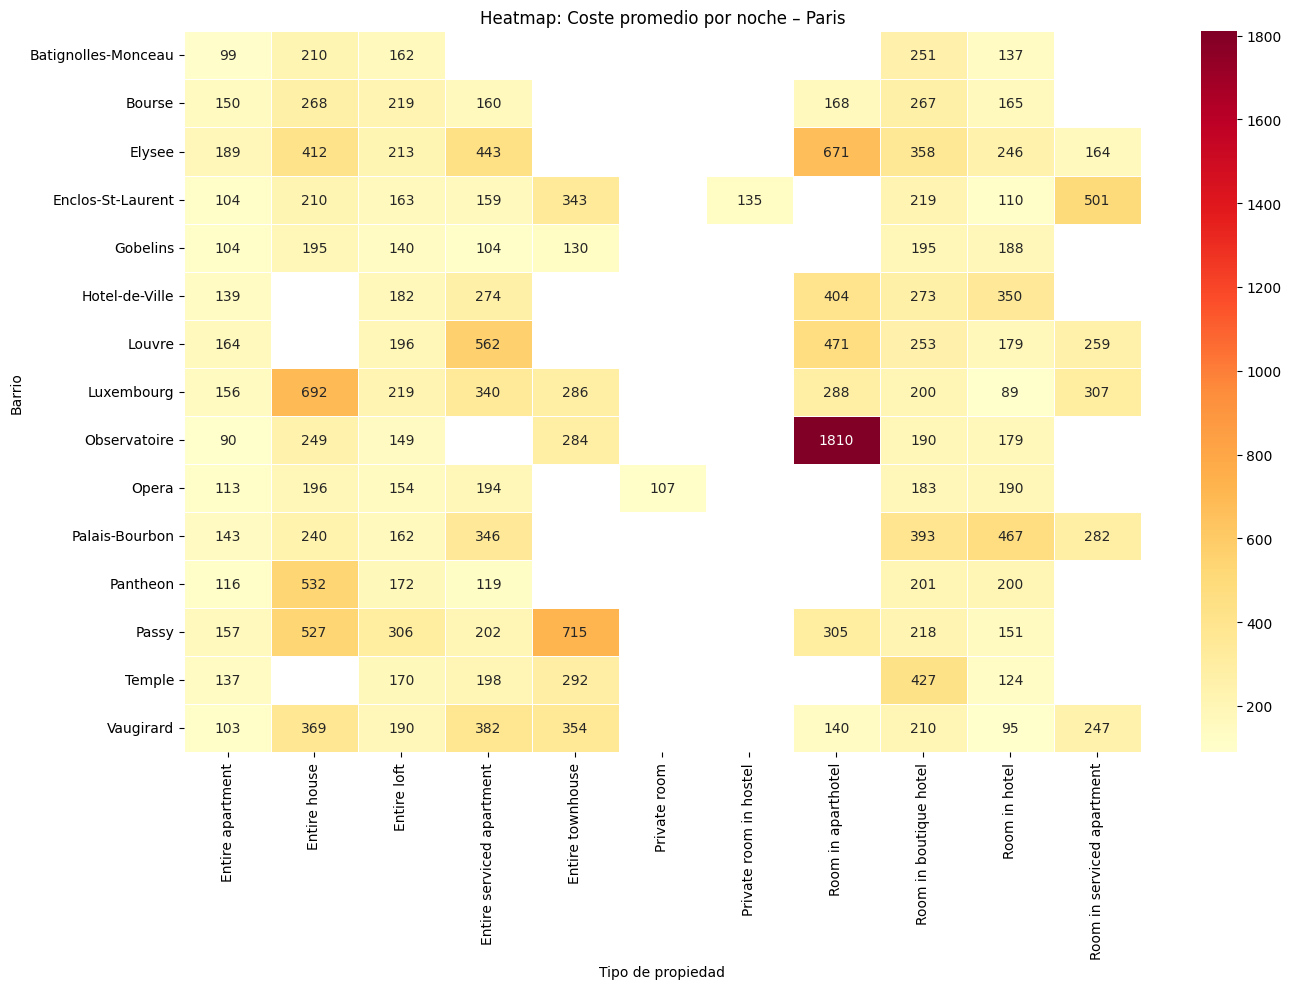

In [7]:
pdf_neigh = media_price_x_neighbourhood.limit(20).toPandas()
pdf_prop  = media_price_x_property.toPandas()

pdf_pivot = heatmap_df.toPandas()
top_neigh = pdf_neigh.head(15)["neighbourhood"].tolist()
top_prop  = pdf_prop.head(12)["property_type"].tolist()

heatmap_data = pdf_pivot[
    pdf_pivot["neighbourhood"].isin(top_neigh) &
    pdf_pivot["property_type"].isin(top_prop)
].pivot(index="neighbourhood", columns="property_type", values="media_price")

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5)
plt.title(f"Heatmap: Coste promedio por noche – {ciudad}")
plt.ylabel("Barrio")
plt.xlabel("Tipo de propiedad")
plt.tight_layout()
plt.show()

La visualización mediante heatmap permite orientarse dentro de la matriz barrio-tipo de propiedad, para rapidamente encontrar aquellas convinaciones con un precio por noche mayor.

Este mapa podría orientar tanto a los turistas, a la hora de escoger mejores precio para un mismo barrio o alojamiento, o incluso a los inversores inmobiliarios que busquen oportunidades de inversión. En particular, salta a la vista que la convinación mejor valorada son las _abitaciones en apartahoteles_ en el barrio _Observatoire_. Así mismo, se aprecia como en ciertos barrios no se pueden encontrar algunos de los tipos de propiedades.

###**3.2. ¿Qué relación existe entre la valoración media (review_scores_rating) y el precio?**
**Objetivo:** Evaluar si precios más altos están asociados a mejores valoraciones.

**Utilidad:** Ayuda a hosts a decidir si mejorar servicios aumenta la disposición a pagar.

In [11]:
# Limpieza
df = df_raw.select(
    col("price").cast("double"),
    col("review_scores_rating").cast("double")
).dropna()

# Filtramos outliers (percentil 99).
price_99 = df.stat.approxQuantile("price", [0.99], 0.01)[0]
df = df.filter(col("price") <= price_99 * 1.5)

# Ejecución de la correlación
corr = df.stat.corr("price", "review_scores_rating")
print("Correlación entre el precio y la valoración promedio:", corr)

Correlación entre el precio y la valoración promedio: 0.015047699005412245


#### **3.2.2. Visualización**

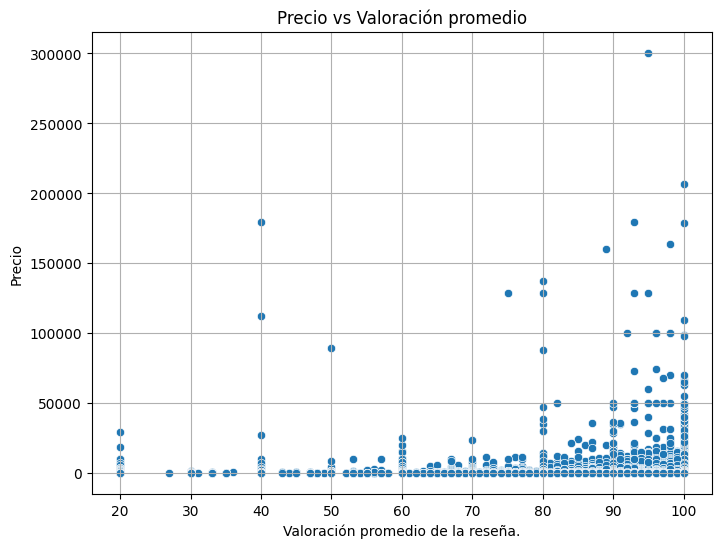

In [12]:
pdf = df.toPandas()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pdf,
    x="review_scores_rating",
    y="price",
)

plt.xlabel("Valoración promedio de la reseña.")
plt.ylabel("Precio")
plt.title("Precio vs Valoración promedio")
plt.grid(True)
plt.show()

Tal y como se advertía en la ejecución del análisis, las valoraciones y el precio no tienen correlación. Esto indica que los arrendatarios ajustan sus expectativas al precio por noche, y reseñan en consecuencia.

Sin embargo, esta visualización nos permite ver que los usuarios tienden a votar numeros redondos, ya que los puntos se agrupan entorno a los múltiplos de diez. Además, los valores más extremos del precio obtienen muy buenas calificaciones, pudiendo indicar que los outliers más lujosos si son valorados positivamente (al ser atípicos no contribuyen a la correlación).

###**3.3. ¿Qué barrios presentan mayor concentración de anuncios en comparación con el total de la ciudad?**
**Objetivo:** Medir qué zonas acumulan proporcionalmente más anuncios dentro del total del mercado Airbnb de la ciudad.

**Utilidad:** Permite identificar zonas con mayor actividad turística o donde los hosts se concentran, lo cual es útil para estudios de saturación, planificación urbana o posicionamiento estratégico para nuevos anfitriones.

In [13]:
# Escogemos la ciudad más popular (París) para realizar el análisis.
ciudad = df_raw.groupBy("city").count().orderBy(desc("count")).first()["city"]
df_ciudad = df_raw.filter(col("city") == ciudad)

# Nos quedamos con la columna que nos interesa.
df = df_ciudad.select("neighbourhood").dropna()

# Número de listings por barrio.
nb_listings = (
    df.groupBy("neighbourhood")
         .agg(count("*").alias("listing_count"))
)

# Número total de listings.
total_listings = nb_listings.agg(sum("listing_count")).first()[0]

# Porcentaje realtivo al total.
nb_proporcion = (
    nb_listings
    .withColumn("share_of_city", round(col("listing_count") / total_listings * 100, 2))
    .orderBy(col("listing_count").desc())
)

#### **3.3.2. Visualización**

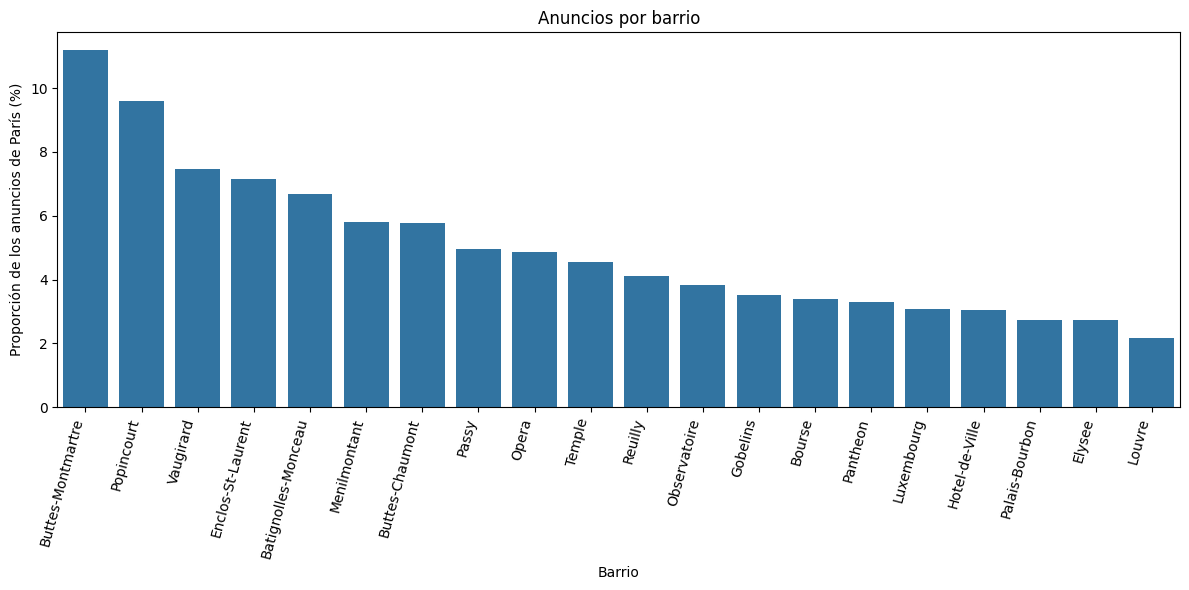

In [14]:
pdf_nb = nb_proporcion.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf_nb,
    x="neighbourhood",
    y="share_of_city",
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Barrio")
plt.ylabel("Proporción de los anuncios de París (%)")
plt.title("Anuncios por barrio")
plt.tight_layout()
plt.show()

###**3.4. ¿Que tres ciudades presentan la mayor varianza en el precio por noche?**
**Objetivo:** Encontrar las ciudades con mayor disparidad entre los precios de los alojamientos.

**Utilidad:** Permite a los usuarios encontrar destinos que se ajusten mejor a su presupuesto, y a los host conocer que mercados son más competitivos.

In [15]:
# Calculamos la varianza del precio por ciudad
varianza_por_ciudad = (df_raw
    .groupBy("city")
    .agg(
        variance("price").alias("price_varianza"),
        count("*").alias("listings"),
        mean("price").alias("media_price"),
        stddev("price").alias("std_dev")
    )
    .filter(col("listings") >= 100)    # solo ciudades con suficiente muestra
    .orderBy(col("price_varianza").desc())
)

# 3. Seleccionamos las 3 ciudades con mayor varianza
top3_ciudades = [row["city"] for row in varianza_por_ciudad.select("city").limit(3).collect()]
print(f"\nLas 3 ciudades con mayor varianza → {top3_ciudades}")


Las 3 ciudades con mayor varianza → ['Bangkok', 'Cape Town', 'Mexico City']


#### **3.4.2. Visualización**

/tmp/ipython-input-4004433793.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pdf_top3, x="city", y="price", inner=None, palette="Set2", bw_adjust=.5, linewidth=1.5)


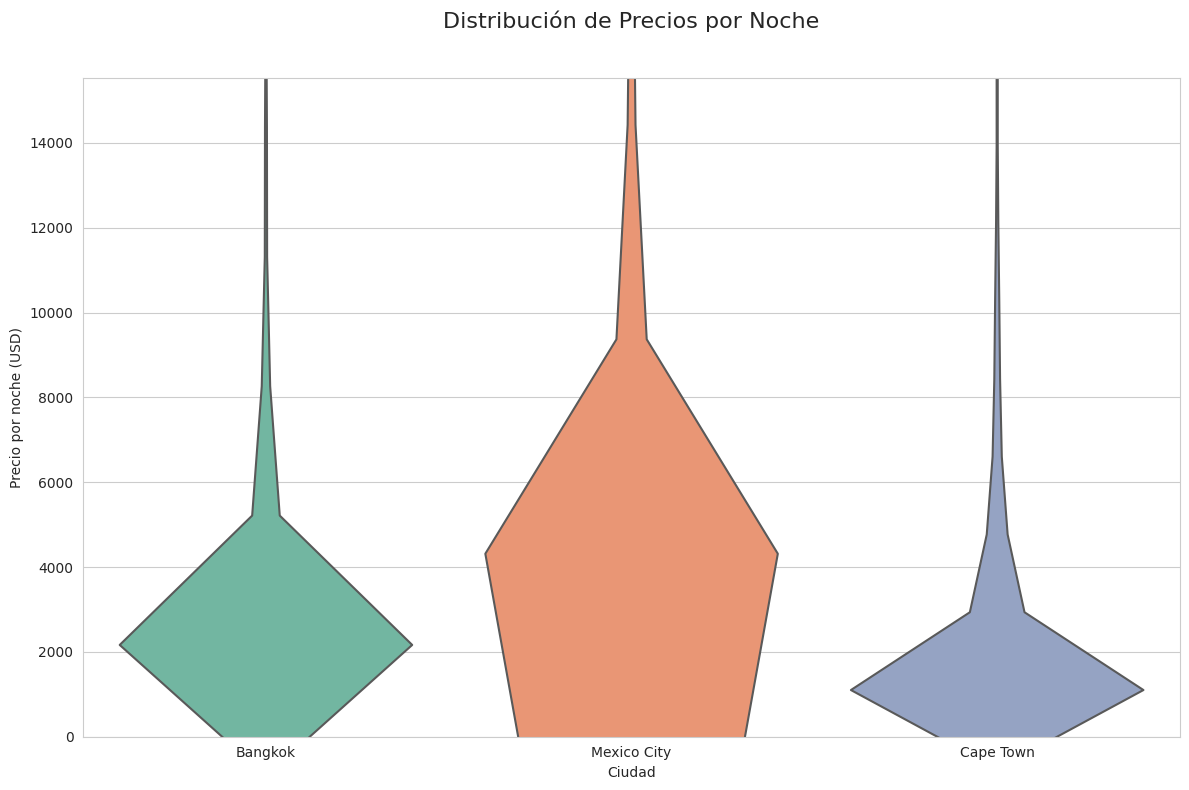

In [16]:
df_top3 = df_raw.filter(col("city").isin(top3_ciudades)) \
                  .select("city", "price")

# Convertir a Pandas para Seaborn
pdf_top3 = df_top3.toPandas()

# Violin plot con Seaborn
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Violinplot
sns.violinplot(data=pdf_top3, x="city", y="price", inner=None, palette="Set2", bw_adjust=.5, linewidth=1.5)

plt.title("Distribución de Precios por Noche\n",
          fontsize=16, pad=20)
plt.ylabel("Precio por noche (USD)")
plt.xlabel("Ciudad")
plt.ylim(0, pdf_top3["price"].quantile(0.99))

plt.tight_layout()
plt.show()

Se ha escogido el _ViolinPlot_ de _Seaborn_ puesto que permite ver distribuciones de una métrica, en este caso el precio, para instancias distintas, en este caso ciudades.

Se aprecia como las tres ciudades agrupan la mayoría de los precios en los rangos más ecónomicos, pero depués tienen largas colas que contienen alojamientos más costosos.

###**3.5. ¿Cual ha sido el precio medio por noche a lo largo de los años?**
**Objetivo:** Identificar la evolución del precio.

**Utilidad:** Puede mostrar tendencias o efectos de la inflación que ayuden predecir rentabilidades a los arrendadores.

In [18]:
# Cargamos el dataset con las fechas
df_reviews = spark.read.csv(
    f"{path}/Airbnb Data/Reviews.csv",
    header=True,
    inferSchema=True
).select(
    col("listing_id"),
    col("date")
)
df_reviews = df_reviews.withColumn("year", year(col("date")))

# Unimos ambos
df_joined = df_reviews.join(df_raw, on="listing_id", how="inner")

# Precio medio por año
df_anual = (
    df_joined.groupBy("year")
             .agg(avg("price").alias("media_price"))
             .orderBy("year")
)

df_anual.show()

+----+------------------+
|year|       media_price|
+----+------------------+
|2008|              37.0|
|2009| 84.94782608695652|
|2010|311.96844660194176|
|2011|414.78122501199425|
|2012| 287.6337215139042|
|2013| 248.1196706385337|
|2014| 360.0881095863492|
|2015|344.63532525719506|
|2016| 350.4079050690179|
|2017| 388.6586039629439|
|2018|388.15996992549645|
|2019| 411.4971442493814|
|2020|440.60298626814455|
|2021|  470.327436853807|
+----+------------------+



#### **3.5.2. Visualización**

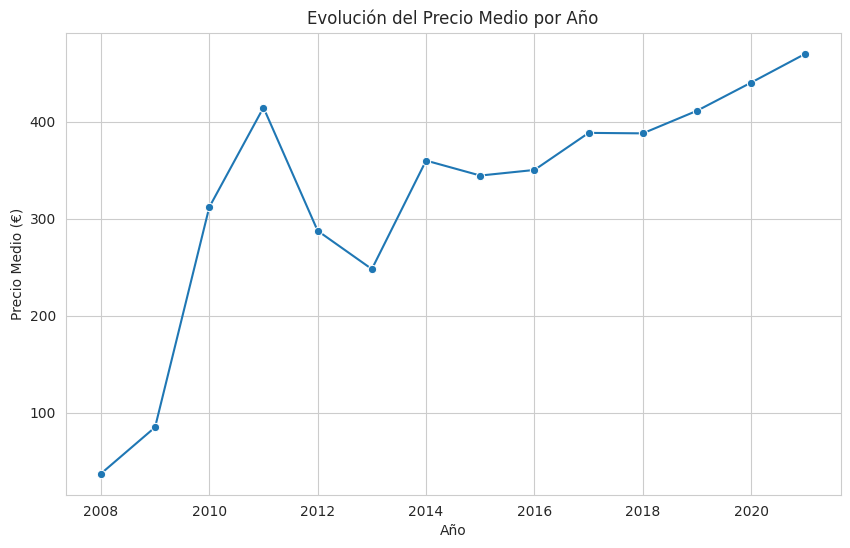

In [19]:
pdf_anual = df_anual.toPandas().sort_values("year")

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=pdf_anual,
    x="year",
    y="media_price",
    marker="o"
)

plt.title("Evolución del Precio Medio por Año")
plt.xlabel("Año")
plt.ylabel("Precio Medio (€)")
plt.grid(True)
plt.show()

**3.6. ¿Cuáles son los hosts “profesionales” (muchas propiedades) y cómo difieren sus precios de los hosts particulares?**

Objetivo: Clasificar actividad profesional.

Utilidad: Informar sobre impacto empresarial vs. individual en el mercado y las posibles diferencias de precios.

In [20]:
# 1. Contar el número de listings por host
df_hosts = (df_raw
    .groupBy("host_id")
    .agg(
        count("*").alias("propiedades_por_host"),
        mean("price").alias("precio_medio_host")
    )
    # Unimos con df_raw para tener la columna 'price' de vuelta
    .join(df_raw, on="host_id", how="inner")
)

# 2. Definir la clasificación de host (ej. 'Profesional' si tiene > 5 propiedades, 'Particular' si tiene <= 5)
# El umbral de 5 es un ejemplo, se puede ajustar.
df_hosts_clasificado = (df_hosts
    .withColumn(
        "tipo_host",
        when(col("propiedades_por_host") > 5, "Profesional")
        .otherwise("Particular")
    )
)

# 3. Calcular el precio medio para cada tipo de host
precio_medio_por_tipo = (df_hosts_clasificado
    .groupBy("tipo_host")
    .agg(
        avg("price").alias("precio_medio"),
        count("*").alias("total_anuncios")
    )
    .orderBy(col("precio_medio").desc())
)

precio_medio_por_tipo.show()

+-----------+-----------------+--------------+
|  tipo_host|     precio_medio|total_anuncios|
+-----------+-----------------+--------------+
|Profesional|941.1494818830635|         58288|
| Particular|521.3026275381169|        221424|
+-----------+-----------------+--------------+



**3.6.2. Visualización**

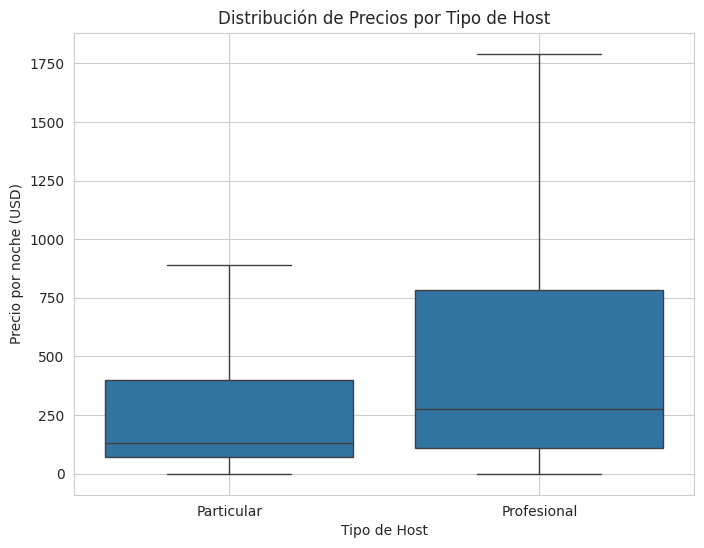

In [21]:
# Convertir a Pandas para Seaborn/Matplotlib
pdf_host_clasif = df_hosts_clasificado.select("price", "tipo_host").toPandas()

plt.figure(figsize=(8, 6))
# Usamos un boxplot para ver la distribución de precios por tipo de host
sns.boxplot(
    data=pdf_host_clasif,
    x="tipo_host",
    y="price",
    # Limitamos el eje y al percentil 95 para manejar outliers visualmente
    showfliers=False
)

plt.title("Distribución de Precios por Tipo de Host")
plt.xlabel("Tipo de Host")
plt.ylabel("Precio por noche (USD)")
plt.grid(True)
plt.show()

**3.7. ¿Qué relación existe entre la longevidad del host (host_since) y su rating (review_scores_rating)?**

Objetivo: Analizar si los hosts con más experiencia reciben mejores valoraciones.

Utilidad: Permite inferir la relación entre la experiencia del host y su respectiva valoración.

In [22]:
from pyspark.sql.functions import to_date, lit, year, max

# 1. Convertir 'host_since' a tipo fecha
df_longevidad = df_raw.withColumn("host_since_date", to_date(col("host_since"), "yyyy-MM-dd"))

# 2. Calcular la antigüedad en años
# Obtenemos el año más reciente de los datos para calcular la longevidad
max_date = df_longevidad.agg(max(col("host_since_date"))).collect()[0][0]

df_longevidad = (df_longevidad
    .withColumn(
        "host_longevidad_años",
        year(lit(max_date)).cast("integer") - year(col("host_since_date")).cast("integer")
    )
    .select("host_longevidad_años", "review_scores_rating")
    .dropna()
)

# 3. Calcular la correlación entre longevidad y rating
corr_longevidad = df_longevidad.stat.corr("host_longevidad_años", "review_scores_rating")
print("Correlación entre longevidad del host y rating:", corr_longevidad)

# 4. Agrupar por longevidad para ver el rating medio (para visualización)
df_longevidad_media = (df_longevidad
    .groupBy("host_longevidad_años")
    .agg(
        avg("review_scores_rating").alias("rating_promedio"),
        count("*").alias("listings")
    )
    .filter(col("listings") >= 100) # Solo años con suficiente muestra
    .orderBy("host_longevidad_años")
)

df_longevidad_media.show(10)

Correlación entre longevidad del host y rating: 0.0774112865547538
+--------------------+-----------------+--------+
|host_longevidad_años|  rating_promedio|listings|
+--------------------+-----------------+--------+
|                   0|90.43867924528301|     212|
|                   1|90.53050124944878|    6803|
|                   2|91.77744014250537|   19087|
|                   3|92.64432610050422|   17651|
|                   4|93.33889964058612|   18085|
|                   5|93.75863290242607|   28235|
|                   6|93.75007073469773|   31809|
|                   7|94.07529954930197|   27291|
|                   8| 94.2240122543841|   18932|
|                   9|93.89049570177554|   12447|
+--------------------+-----------------+--------+
only showing top 10 rows



**3.7.2. Visualización**

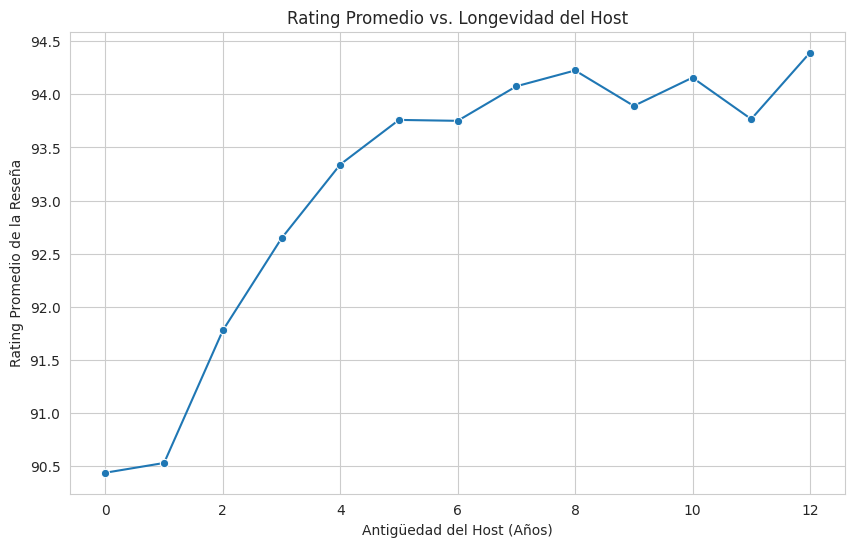

In [23]:
# Convertir a Pandas
pdf_longevidad = df_longevidad_media.toPandas()

plt.figure(figsize=(10, 6))
# Usamos un lineplot para ver la tendencia del rating a medida que la longevidad aumenta
sns.lineplot(
    data=pdf_longevidad,
    x="host_longevidad_años",
    y="rating_promedio",
    marker='o'
)

plt.title("Rating Promedio vs. Longevidad del Host")
plt.xlabel("Antigüedad del Host (Años)")
plt.ylabel("Rating Promedio de la Reseña")
plt.grid(True)
plt.show()

**3.8. ¿Qué ciudad genera, en promedio, una menor puntuación en cuanto a la limpieza del alojamiento (review_scores_cleanliness)?**

Objetivo: Encontrar la ciudad que en promedio tiene los pisos menos limpios.

Utilidad: Permite advertir a posibles turistas las condiciones de higiene que se dan en distintos destinos turísticos.

In [24]:
# 1. Calcular la puntuación media de limpieza por ciudad
df_limpieza_ciudad = (df_raw
    .filter(col("review_scores_cleanliness").isNotNull())
    .groupBy("city")
    .agg(
        avg("review_scores_cleanliness").alias("media_limpieza"),
        count("*").alias("listings")
    )
    .filter(col("listings") >= 100) # Filtramos ciudades con suficiente muestra
    .orderBy(col("media_limpieza").asc()) # Ordenamos de menor a mayor media
)

# 2. Obtener la ciudad con la media de limpieza más baja (y las siguientes)
df_limpieza_ciudad.show(5)

+---------+-----------------+--------+
|     city|   media_limpieza|listings|
+---------+-----------------+--------+
|Hong Kong|8.992323980942297|    3778|
| Istanbul| 9.05427807486631|   11220|
|    Paris|9.206446101920914|   47998|
|   Sydney|9.206995387164675|   22329|
| New York| 9.26800926617845|   26764|
+---------+-----------------+--------+
only showing top 5 rows



**3.8.2. Visualización**

/tmp/ipython-input-2508992693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


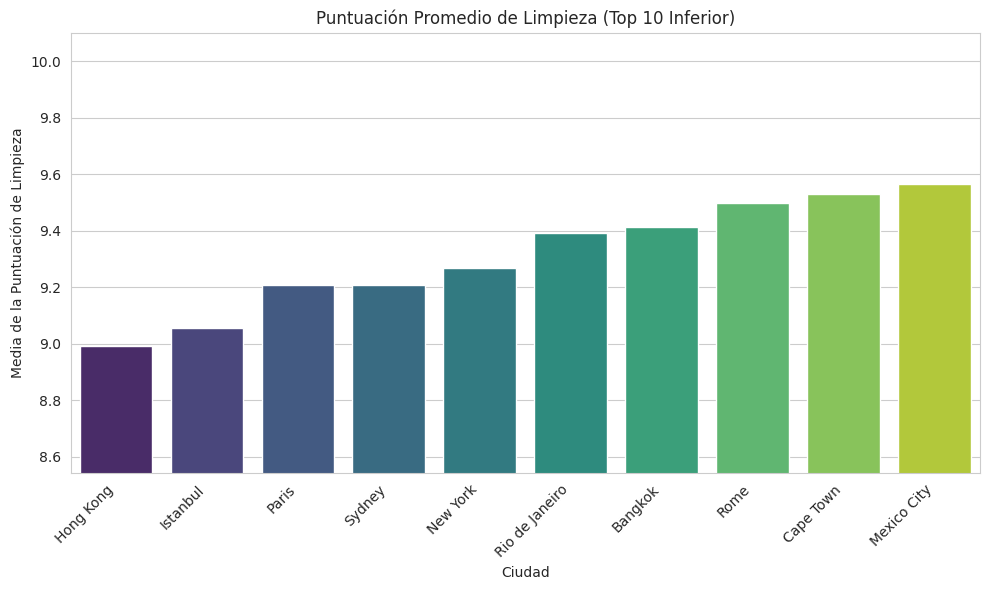

In [25]:
# Convertir a Pandas para el gráfico (tomando las 10 peores)
pdf_limpieza = df_limpieza_ciudad.limit(10).toPandas()

plt.figure(figsize=(10, 6))
# Usamos un barplot para comparar las medias de las 10 ciudades con menor puntuación
sns.barplot(
    data=pdf_limpieza,
    x="city",
    y="media_limpieza",
    palette="viridis"
)

plt.xticks(rotation=45, ha="right")
plt.title("Puntuación Promedio de Limpieza (Top 10 Inferior)")
plt.xlabel("Ciudad")
plt.ylabel("Media de la Puntuación de Limpieza")
plt.ylim(pdf_limpieza["media_limpieza"].min() * 0.95, 10.1) # Puntuación máxima es 10.0
plt.tight_layout()
plt.show()

**3.9. ¿Cuál es la relación entre el número de noches mínimas y el máximo de noches de estancia?**

Objetivo: Analizar cómo la política de noches mínimas se relaciona con la política de noches máximas.

Utilidad: Permite a los hosts entender si un mínimo alto se asocia con políticas más restrictivas o más flexibles para estancias largas.

In [30]:
from pyspark.sql.functions import col, avg, count

# 1. Seleccionar columnas y asegurar tipos de datos
df_min_max_noches = (df_raw
    .select(
        col("minimum_nights").cast("integer"),
        col("maximum_nights").cast("integer") # Usamos 'maximum_nights' como métrica disponible
    )
    .filter(col("minimum_nights").isNotNull() & col("maximum_nights").isNotNull())
)

# 2. Agrupar por 'minimum_nights' y calcular la media de 'maximum_nights'
# Limitamos 'minimum_nights' hasta 30 para enfocarnos en políticas comunes.
df_relacion_politica = (df_min_max_noches
    .filter(col("minimum_nights") <= 30)
    .groupBy("minimum_nights")
    .agg(
        avg("maximum_nights").alias("media_max_noches"),
        count("*").alias("listings")
    )
    .filter(col("listings") >= 100) # Usando el umbral de 100 listings para una muestra suficiente
    .orderBy("minimum_nights")
)

df_relacion_politica.show(10)

+--------------+------------------+--------+
|minimum_nights|  media_max_noches|listings|
+--------------+------------------+--------+
|             1|11775.346276887945|   92839|
|             2| 71213.24859963534|   60877|
|             3| 634.9769468430643|   37869|
|             4| 596.2181860609832|   12856|
|             5|1315.7464778503995|   13770|
|             6| 580.8968596946125|    3471|
|             7| 559.7787072912997|   11356|
|             8| 499.6984126984127|     504|
|             9| 526.8104265402843|     211|
|            10|  538.796797153025|    2810|
+--------------+------------------+--------+
only showing top 10 rows



**3.9.2. Visualización**

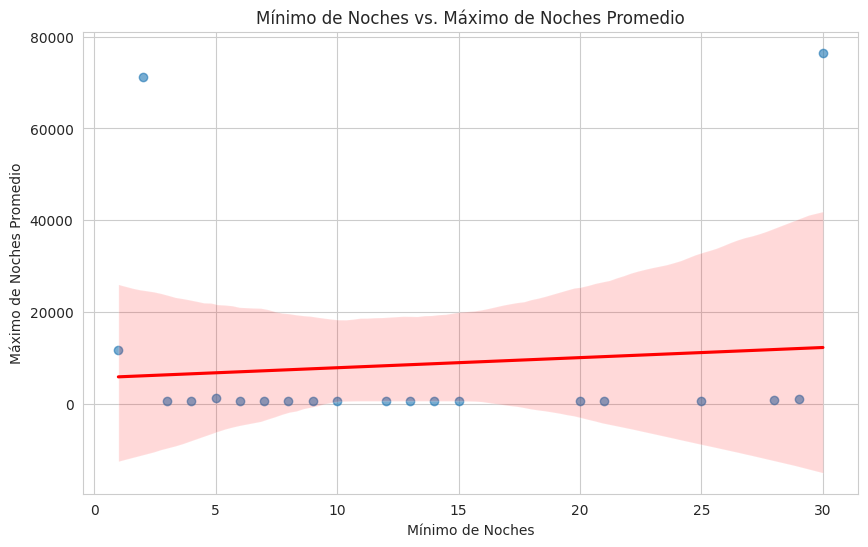

In [31]:
# Convertir a Pandas
pdf_politica = df_relacion_politica.toPandas()

plt.figure(figsize=(10, 6))
# Usamos un regplot para ver la tendencia entre las dos políticas
sns.regplot(
    data=pdf_politica,
    x="minimum_nights",
    y="media_max_noches",
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title("Mínimo de Noches vs. Máximo de Noches Promedio")
plt.xlabel("Mínimo de Noches")
plt.ylabel("Máximo de Noches Promedio")
plt.grid(True)
plt.show()

**3.10. ¿En qué barrios la diferencia entre precio listado y valoración es más extrema (caro con malas reviews o barato con buenas reviews)?**

Objetivo: Detectar comportamientos anómalos de mercado.

Utilidad: Oportunidades para inversión o indicadores de problemas de calidad.

In [28]:
from pyspark.sql.functions import stddev, abs

# 1. Filtramos los datos necesarios
df_anomalias = df_raw.select("neighbourhood", "price", "review_scores_rating").dropna()

# 2. Calculamos las medias y desviaciones estándar
media_precio = df_anomalias.agg(mean("price")).first()[0]
std_precio = df_anomalias.agg(stddev("price")).first()[0]
media_rating = df_anomalias.agg(mean("review_scores_rating")).first()[0]
std_rating = df_anomalias.agg(stddev("review_scores_rating")).first()[0]

# 3. Calculamos el Z-score para cada métrica y el score de anomalía (Z_price - Z_rating)
df_anomalias = (df_anomalias
    .withColumn("z_price", (col("price") - media_precio) / std_precio)
    .withColumn("z_rating", (col("review_scores_rating") - media_rating) / std_rating)
    # Score Positivo alto: Caro (z_price alto) con Rating Bajo (z_rating bajo) -> Caros y Malos
    # Score Negativo alto: Barato (z_price bajo) con Rating Alto (z_rating alto) -> Baratos y Buenos
    .withColumn("score_anomalia", col("z_price") - col("z_rating"))
)

# 4. Agrupamos por barrio y obtenemos la media del score de anomalía
df_barrio_anomalia = (df_anomalias
    .groupBy("neighbourhood")
    .agg(
        avg("score_anomalia").alias("media_anomalia"),
        count("*").alias("listings")
    )
    .filter(col("listings") >= 50) # Solo barrios con suficiente muestra
    .orderBy(abs(col("media_anomalia")).desc()) # Ordenamos por el valor absoluto más extremo
)

df_barrio_anomalia.show(10)

+-------------+------------------+--------+
|neighbourhood|    media_anomalia|listings|
+-------------+------------------+--------+
|      Ward 54| 1.445457679408157|    1856|
|  Parthum Wan|1.3036373455046693|     341|
|      Ward 62|1.0405435296950578|     396|
|      Pra Wet|0.9987134366475626|      83|
| Sham Shui Po|0.9964856453358659|      66|
|      Ward 74|0.8870903759245587|     664|
|  Khlong Toei|0.8690752554417547|    1586|
|       Sathon|0.8101915691592271|     605|
|     Esenyurt| 0.777641445215362|     210|
|      Vadhana|0.7654622456375876|    1422|
+-------------+------------------+--------+
only showing top 10 rows



**3.10.2. Visualización**

/tmp/ipython-input-2128474713.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-2128474713.py:7: UserWarning: 
The palette list has fewer values (2) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


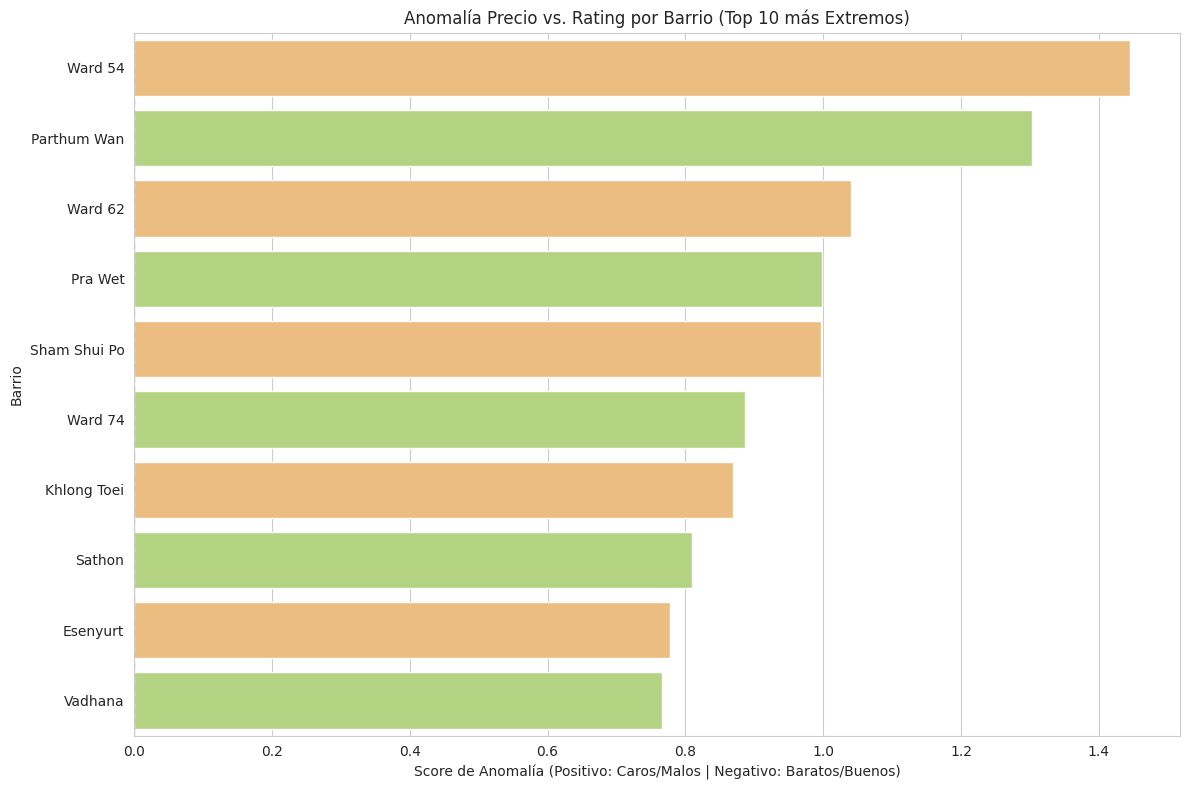

In [29]:
# Convertir a Pandas (tomando los 10 barrios más extremos)
pdf_anomalia = df_barrio_anomalia.limit(10).toPandas()

plt.figure(figsize=(12, 8))

# Usamos un barplot horizontal para facilitar la lectura de los nombres de los barrios
sns.barplot(
    data=pdf_anomalia,
    y="neighbourhood",
    x="media_anomalia",
    palette=sns.color_palette("RdYlGn", 2) # Rojo/Amarillo/Verde: positivo (malo) a negativo (bueno)
)

plt.axvline(0, color='black', linestyle='--') # Línea divisoria en 0
plt.title("Anomalía Precio vs. Rating por Barrio (Top 10 más Extremos)")
plt.xlabel("Score de Anomalía (Positivo: Caros/Malos | Negativo: Baratos/Buenos)")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()